# multiplayer RPG: putting it all together
* lesson 31 built a real (single-player) RPG world: a tile-based map, a `Player` walking around it, `NPC`s standing on tiles, a dialogue system - a whole little game, but only ONE person could ever play it, alone, on their own machine
* lessons 33 and 34 built the opposite half: generic multiplayer networking - sockets, TCP vs UDP, the authoritative-server pattern, and a real (simulated) `asyncio` server where several clients stay in sync with broadcasts
* this lesson is the direct fusion of both: several players connect to ONE authoritative server, walk around the SAME tile-based RPG world, and actually see each other moving and interacting live - a genuine (tiny) multiplayer RPG
* like every game-dev lesson in this course, this notebook is fully self-contained - we quickly recap the tile-map/collision ideas from lesson 31 and the asyncio server/`SimClient` shape from lesson 34 in our own words, we dont import anything from those other notebooks

## recap: the headless pygame setup (lesson 27/31)
* quick reminder, full explanation lives in lesson 27: this sandbox has no real screen, so we point SDL (the library pygame wraps) at its "dummy" video/audio driver and render off-screen into memory only
* both `os.environ[...]` lines MUST run before `import pygame` happens at all
* to actually SEE anything we draw we convert the pygame `Surface` into a numpy array and hand it to matplotlib - the same `show_surface()` helper every game-dev lesson in this course has used

In [1]:
import os

# these two lines MUST run before "import pygame" - same trick every game-dev lesson in this course uses
os.environ["SDL_VIDEODRIVER"] = "dummy"   # render off-screen instead of trying to open a real window
os.environ["SDL_AUDIODRIVER"] = "dummy"   # no real sound device attached to this sandbox either

import asyncio
import json
import pygame
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass  # recap lesson 31 - a clean way to bundle a tile type's data together

pygame.init()
print("pygame initialized, version:", pygame.version.ver)


def show_surface(surface, title=None, figsize=(5, 4)):
    """Render a pygame Surface inline in the notebook (recap lesson 27)."""
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)  # pygame is (w,h,c), matplotlib wants (h,w,c)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")  # a game screenshot doesnt need axis ticks
    if title:
        plt.title(title, fontsize=10)
    plt.show()

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame initialized, version: 2.6.1


## the shared world - ONE map, owned by the server
* this is the single most important idea in this whole lesson: there is only ONE real copy of the map, and it lives on the SERVER - every client just gets TOLD what the map looks like and what is happening on it, nobody's client ever gets to change the real thing
* we reuse lesson 31's tile-map style: the map is a plain list of strings (one string per row, one character per tile), and a small `TileType` dataclass bundles each tile character's color + whether you can walk on it
* `T` = tree/wall (blocks movement), `.` = grass (walkable), `,` = a stone path (walkable, just a different look), `~` = water (blocks movement)
* `is_walkable(x, y)` is going to become our server's authoritative collision check, recap lesson 31/33 - it checks the map bounds AND the tile's walkable flag, and it is the ONLY code allowed to decide whether a move is legal

shared world is 10x8 tiles (320x256 pixels)


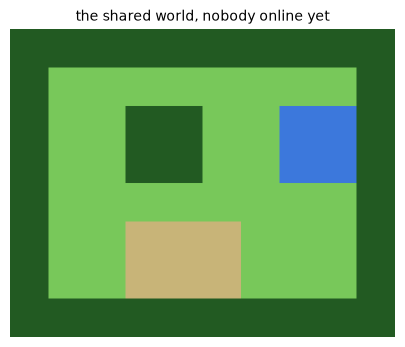

In [2]:
@dataclass
class TileType:
    """A plain data record for one kind of tile - just data, no behaviour (recap lesson 31's dataclass use)."""
    color: tuple    # (r, g, b) used to draw this tile type
    walkable: bool  # can a player stand on this tile?


TILE_TYPES = {
    "T": TileType(color=(34, 90, 34), walkable=False),    # tree/wall - blocks movement
    ".": TileType(color=(120, 200, 90), walkable=True),   # grass - walkable
    ",": TileType(color=(200, 180, 120), walkable=True),  # stone path - walkable, just a different look
    "~": TileType(color=(60, 120, 220), walkable=False),  # water - blocks movement, no swimming here
}

TILE_SIZE = 32  # pixels per tile

# our little shared village - every connected player is going to be walking around on THIS exact map
WORLD_MAP = [
    "TTTTTTTTTT",
    "T........T",
    "T..TT..~~T",
    "T..TT..~~T",
    "T........T",
    "T..,,,...T",
    "T..,,,...T",
    "TTTTTTTTTT",
]

MAP_COLS = len(WORLD_MAP[0])  # 10 tiles wide
MAP_ROWS = len(WORLD_MAP)     # 8 tiles tall
print(f"shared world is {MAP_COLS}x{MAP_ROWS} tiles ({MAP_COLS * TILE_SIZE}x{MAP_ROWS * TILE_SIZE} pixels)")


def is_walkable(x, y):
    """THE authoritative collision check - bounds first, then the tile's own walkable flag (recap lesson 31)."""
    if not (0 <= y < MAP_ROWS) or not (0 <= x < MAP_COLS):  # off the map entirely -> never walkable
        return False
    return TILE_TYPES[WORLD_MAP[y][x]].walkable


def render_map(surface, world_map, tile_size):
    """Classic tile-rendering technique (recap lesson 31): loop rows/cols, draw one rect per tile."""
    for row_index, row in enumerate(world_map):
        for col_index, tile_char in enumerate(row):
            color = TILE_TYPES[tile_char].color
            pixel_rect = (col_index * tile_size, row_index * tile_size, tile_size, tile_size)
            pygame.draw.rect(surface, color, pixel_rect)


# a quick sanity render, no players on it yet - just proving the map itself draws correctly
_preview = pygame.Surface((MAP_COLS * TILE_SIZE, MAP_ROWS * TILE_SIZE))
render_map(_preview, WORLD_MAP, TILE_SIZE)
show_surface(_preview, title="the shared world, nobody online yet")

## the authoritative server - recap lesson 34's exact shape
* just like lesson 34's server, we keep the REAL, true state in a couple of plain module-level dicts that only server-side code (`handle_client`) is ever allowed to touch: `PLAYER_STATE` (every connected player's position/name/color) and `CONNECTIONS` (every connected player's `StreamWriter`, so we can push messages to them)
* whenever ANY player successfully (or unsuccessfully!) tries to move, we run the authoritative wall-check from the cell above and then broadcast the whole updated player list to EVERYONE - the exact "broadcast on change" pattern lesson 34 taught us
* we add one RPG-specific extra: an `emote`/chat message type, so connected players can actually say short things to each other, recap lesson 34's exercise 1 chat pattern - broadcast to everyone connected, for now (exercise 3 below tightens this up with a distance filter)
* recap lesson 11/34: `asyncio`'s single-threaded event loop means there is never a moment where two pieces of code are touching `PLAYER_STATE` at the exact same instant - no locks needed, no race conditions, even with many players connected at once

In [3]:
# --- the server's ONE real copy of who is online and where they are - recap lesson 34's shape exactly ---
PLAYER_STATE = {}      # player_id -> {"x", "y", "name", "color"} - the REAL position+identity of every player
CONNECTIONS = {}       # player_id -> the StreamWriter used to push messages TO that one player
NEXT_PLAYER_NUM = [1]  # a mutable single-element list, so handle_client can bump a counter shared across connections

# a small palette so every new player automatically gets a different, easy-to-tell-apart marker color
PLAYER_COLORS = [(220, 60, 60), (60, 120, 220), (60, 200, 90), (230, 190, 60), (190, 90, 220)]


async def broadcast_state():
    """Push the current, real PLAYER_STATE to EVERY connected client - this is how everyone stays in sync."""
    message = (json.dumps({"type": "state", "players": dict(PLAYER_STATE)}) + "\n").encode()
    for writer in CONNECTIONS.values():
        writer.write(message)
        await writer.drain()  # wait until the OS actually accepted the bytes, recap asyncio streams


async def broadcast_chat(player_id, text):
    """Broadcast one chat/emote line from `player_id` to EVERYONE currently connected."""
    message = (json.dumps({
        "type": "chat", "player_id": player_id, "name": PLAYER_STATE[player_id]["name"], "text": text,
    }) + "\n").encode()
    for writer in CONNECTIONS.values():
        writer.write(message)
        await writer.drain()


async def handle_client(reader, writer):
    """Runs once PER connected player, for as long as they stay connected - the RPG version of lesson 34's coroutine."""
    # every client's very FIRST message must be a "hello" carrying their chosen display name - like naming your character
    hello = json.loads(await reader.readline())

    player_id = f"player{NEXT_PLAYER_NUM[0]}"
    color = PLAYER_COLORS[(NEXT_PLAYER_NUM[0] - 1) % len(PLAYER_COLORS)]  # cycle through the palette per new player
    NEXT_PLAYER_NUM[0] += 1

    # everyone spawns on the same walkable starting tile - recap lesson 31's player always starting top-left-ish
    PLAYER_STATE[player_id] = {"x": 1, "y": 1, "name": hello["name"], "color": list(color)}
    CONNECTIONS[player_id] = writer

    writer.write((json.dumps({"type": "welcome", "player_id": player_id}) + "\n").encode())
    await writer.drain()
    await broadcast_state()  # let everyone (including the brand new player) see the updated player list right away

    try:
        while True:
            line = await reader.readline()  # readline() gives us framing for free, recap lesson 33/34
            if not line:  # an empty read means this client's connection closed
                break
            request = json.loads(line)

            if request["type"] == "move":
                # THE authoritative check - the client only ever REQUESTS a move, the server decides what really happens
                current = PLAYER_STATE[player_id]
                new_x, new_y = current["x"] + request["dx"], current["y"] + request["dy"]
                if is_walkable(new_x, new_y):
                    current["x"], current["y"] = new_x, new_y
                await broadcast_state()  # broadcast either way - even a rejected move tells everyone "nothing changed"

            elif request["type"] == "chat":
                await broadcast_chat(player_id, request["text"])
    finally:
        # runs no matter HOW the client went away (clean quit, crash, network drop) - recap lesson 34's finally block
        PLAYER_STATE.pop(player_id, None)
        CONNECTIONS.pop(player_id, None)
        await broadcast_state()  # let the remaining players see that this player is gone


rpg_server = await asyncio.start_server(handle_client, "127.0.0.1", 0)
rpg_port = rpg_server.sockets[0].getsockname()[1]
print(f"multiplayer RPG server listening on 127.0.0.1:{rpg_port}")

multiplayer RPG server listening on 127.0.0.1:46499


## `RPGSimClient` - what a real RPG client's networking looks like
* this is lesson 34's `SimClient` idea, adapted for our RPG: `.connect()` opens the connection, sends our chosen display name, and starts a background `asyncio.create_task()` listener that keeps recording every broadcast into `.history` for as long as we're connected
* `.move(dx, dy)` sends a move REQUEST (recap lesson 33: the client proposes, the server decides), `.say(text)` sends a chat/emote request, `.disconnect()` closes cleanly
* `.latest_state` and `.chat_log` are small conveniences that dig the most recent/relevant entries back out of `.history` - exactly what a real game client would do to decide what to draw on screen right now

In [4]:
class RPGSimClient:
    """Stands in for "one player's RPG game client" - connects, listens in the background, sends requests."""

    def __init__(self, name):
        self.name = name        # this player's chosen display name
        self.history = []       # every broadcast this client has ever received, in order - "what did this player see"
        self.player_id = None   # filled in once the server's "welcome" message arrives

    async def connect(self):
        self.reader, self.writer = await asyncio.open_connection("127.0.0.1", rpg_port)
        # our very first message MUST be "hello" with our chosen name - the server is waiting for exactly this
        self.writer.write((json.dumps({"type": "hello", "name": self.name}) + "\n").encode())
        await self.writer.drain()
        welcome = json.loads(await self.reader.readline())
        self.player_id = welcome["player_id"]
        self._listen_task = asyncio.create_task(self._listen_forever())  # keeps running in the background from now on

    async def _listen_forever(self):
        """Runs in the background for this client's whole lifetime, recording every broadcast as it arrives."""
        while True:
            line = await self.reader.readline()
            if not line:
                break
            self.history.append(json.loads(line))

    async def move(self, dx, dy):
        """Send a move REQUEST - only ever a request, the server decides what really happens (recap lesson 31/33)."""
        self.writer.write((json.dumps({"type": "move", "dx": dx, "dy": dy}) + "\n").encode())
        await self.writer.drain()

    async def say(self, text):
        """Send a chat/emote message - our one RPG-specific interaction feature on top of plain movement."""
        self.writer.write((json.dumps({"type": "chat", "text": text}) + "\n").encode())
        await self.writer.drain()

    async def disconnect(self):
        self.writer.close()
        await asyncio.sleep(0.05)  # give the server a moment to actually notice and process the disconnect

    @property
    def latest_state(self):
        """The most recent "state" broadcast this client saw - skips over other message types like "chat"."""
        for entry in reversed(self.history):
            if entry["type"] == "state":
                return entry["players"]
        return {}

    @property
    def chat_log(self):
        """Every chat/emote message this client has ever received, in order."""
        return [entry for entry in self.history if entry["type"] == "chat"]


print("RPGSimClient ready - connects, listens in the background, and can move()/say()/disconnect()")

RPGSimClient ready - connects, listens in the background, and can move()/say()/disconnect()


## three players, sharing the SAME world
* now the real demo: three SEPARATE simulated players connect, walk around independently, and we prove they all end up seeing the exact same, correct shared state - exactly what "multiplayer" means in practice
* we also deliberately send ONE illegal move (straight into the wall bordering the map) for Carol, and confirm the server correctly rejected it, WITHOUT affecting Alice or Bob at all
* generous `asyncio.sleep()` pauses after every connect/move (recap lesson 34) give the background listener tasks time to actually receive and record each broadcast before we go check `.history`

In [5]:
alice = RPGSimClient("Alice")
bob = RPGSimClient("Bob")
carol = RPGSimClient("Carol")

await alice.connect()
await bob.connect()
await carol.connect()
await asyncio.sleep(0.15)  # generous pause - let all three "welcome" + initial broadcasts fully settle

print("right after everyone joined, everyone spawns on the same starting tile:")
print(alice.latest_state)

# alice walks two tiles right along the open top corridor - both steps land on walkable "." tiles
await alice.move(1, 0)
await asyncio.sleep(0.08)
await alice.move(1, 0)
await asyncio.sleep(0.08)

# bob walks two tiles down the open left corridor - also both walkable
await bob.move(0, 1)
await asyncio.sleep(0.08)
await bob.move(0, 1)
await asyncio.sleep(0.08)

# carol deliberately tries to walk STRAIGHT UP into the wall bordering the map - this MUST get rejected
carol_position_before = dict(carol.latest_state[carol.player_id])
await carol.move(0, -1)
await asyncio.sleep(0.1)
carol_position_after = carol.latest_state[carol.player_id]

print()
print("carol's position before the illegal move:", carol_position_before)
print("carol's position after the illegal move: ", carol_position_after)
print("was the illegal move correctly rejected?", carol_position_before == carol_position_after)

print()
print("alice's view of the world:", alice.latest_state)
print("bob's view of the world:  ", bob.latest_state)
print("carol's view of the world:", carol.latest_state)
print("do all three players agree on the exact same state?",
      alice.latest_state == bob.latest_state == carol.latest_state)

right after everyone joined, everyone spawns on the same starting tile:
{'player1': {'x': 1, 'y': 1, 'name': 'Alice', 'color': [220, 60, 60]}, 'player2': {'x': 1, 'y': 1, 'name': 'Bob', 'color': [60, 120, 220]}, 'player3': {'x': 1, 'y': 1, 'name': 'Carol', 'color': [60, 200, 90]}}



carol's position before the illegal move: {'x': 1, 'y': 1, 'name': 'Carol', 'color': [60, 200, 90]}
carol's position after the illegal move:  {'x': 1, 'y': 1, 'name': 'Carol', 'color': [60, 200, 90]}
was the illegal move correctly rejected? True

alice's view of the world: {'player1': {'x': 3, 'y': 1, 'name': 'Alice', 'color': [220, 60, 60]}, 'player2': {'x': 1, 'y': 3, 'name': 'Bob', 'color': [60, 120, 220]}, 'player3': {'x': 1, 'y': 1, 'name': 'Carol', 'color': [60, 200, 90]}}
bob's view of the world:   {'player1': {'x': 3, 'y': 1, 'name': 'Alice', 'color': [220, 60, 60]}, 'player2': {'x': 1, 'y': 3, 'name': 'Bob', 'color': [60, 120, 220]}, 'player3': {'x': 1, 'y': 1, 'name': 'Carol', 'color': [60, 200, 90]}}
carol's view of the world: {'player1': {'x': 3, 'y': 1, 'name': 'Alice', 'color': [220, 60, 60]}, 'player2': {'x': 1, 'y': 3, 'name': 'Bob', 'color': [60, 120, 220]}, 'player3': {'x': 1, 'y': 1, 'name': 'Carol', 'color': [60, 200, 90]}}
do all three players agree on the exact s

## rendering the shared world - from the CLIENT's own received state
* this is the important bit to notice: `render_world_from_state()` below only ever looks at a dict that came out of ONE client's `.history` - it never touches `PLAYER_STATE` on the server directly
* that's exactly how a real multiplayer game client works: it draws whatever it was last TOLD over the network, nothing more, nothing less - if the network told it something wrong or stale, that's what would show up on screen
* each player gets drawn as a little colored circle at their CURRENT tile, using the color the server assigned them when they connected

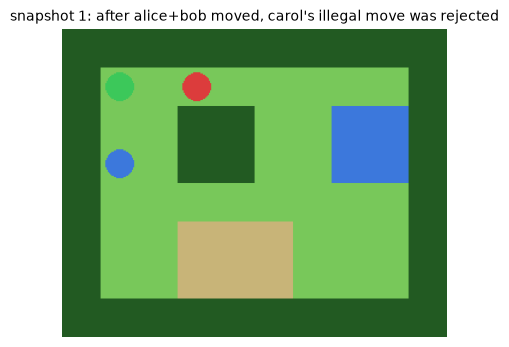

<Surface(320x256x32 SW)>

In [6]:
def render_world_from_state(players, title):
    """Draw the map + every player's marker, built ENTIRELY from a client's own received `players` dict."""
    surface = pygame.Surface((MAP_COLS * TILE_SIZE, MAP_ROWS * TILE_SIZE))
    render_map(surface, WORLD_MAP, TILE_SIZE)  # the tile background - same rendering function from lesson 31
    for player_id, info in players.items():
        pixel_x = info["x"] * TILE_SIZE + TILE_SIZE // 2  # center of that player's current tile, in pixels
        pixel_y = info["y"] * TILE_SIZE + TILE_SIZE // 2
        pygame.draw.circle(surface, tuple(info["color"]), (pixel_x, pixel_y), TILE_SIZE // 2 - 4)
    show_surface(surface, title=title, figsize=(5, 4))
    return surface


# this dict comes straight out of alice's OWN `.history` - what her client was TOLD over the network, nothing else
render_world_from_state(alice.latest_state, "snapshot 1: after alice+bob moved, carol's illegal move was rejected")

## chat/emote - our one RPG-specific interaction feature
* plain movement alone doesnt feel very "RPG" yet - real RPGs let players actually talk to each other (and to NPCs, recap lesson 31's dialogue system)
* we add the simplest version of that: a short chat/emote message, sent to the server and broadcast out to everyone connected, recap lesson 34's exercise-1 chat pattern
* (exercise 3 below improves this into a proper distance-based filter, so you don't hear every single message from across the whole map - for now, everyone connected hears everything)

In [7]:
await alice.say("hey everyone, made it past the wall!")
await asyncio.sleep(0.1)  # give the broadcast a moment to reach bob and carol's listener tasks

print("bob's chat log:  ", bob.chat_log)
print("carol's chat log:", carol.chat_log)
print("did everyone receive alice's message?",
      bob.chat_log[-1]["text"] == carol.chat_log[-1]["text"] == "hey everyone, made it past the wall!")

bob's chat log:   [{'type': 'chat', 'player_id': 'player1', 'name': 'Alice', 'text': 'hey everyone, made it past the wall!'}]
carol's chat log: [{'type': 'chat', 'player_id': 'player1', 'name': 'Alice', 'text': 'hey everyone, made it past the wall!'}]
did everyone receive alice's message? True


## carol catches up
* one more round of movement, this time for carol, so we have three genuinely different positions to look at in our next snapshot

carol's new position: {'x': 2, 'y': 2, 'name': 'Carol', 'color': [60, 200, 90]}


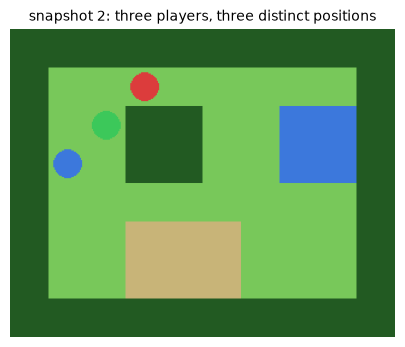

<Surface(320x256x32 SW)>

In [8]:
# carol catches up - two legal moves, landing on tiles nobody else is standing on right now
await carol.move(1, 0)   # (1, 1) -> (2, 1) - alice already moved past this tile, so its free
await asyncio.sleep(0.08)
await carol.move(0, 1)   # (2, 1) -> (2, 2) - also a walkable grass tile
await asyncio.sleep(0.1)

print("carol's new position:", carol.latest_state[carol.player_id])
render_world_from_state(bob.latest_state, "snapshot 2: three players, three distinct positions")

## discussion: what if two players move onto the SAME tile at once?
* here's a question every shared-world multiplayer game has to answer: what happens if two players both try to step onto the exact same tile "at the same time"?
* recap lesson 34's big point about `asyncio`: our server is single-threaded and processes ONE message at a time, from start to finish, before ever looking at the next one - there is no moment where two `move` requests are being handled simultaneously, so there's no data-corruption-style race condition to worry about at all
* but that does NOT automatically mean the second player gets blocked! our current `is_walkable()` check only looks at the MAP (walls/water) - it has no idea another PLAYER might already be standing on the target tile. so whichever move message the server happens to process first simply succeeds, and if the second one ALSO only hits a plain walkable tile, it succeeds too - even though someone is already standing there
* lets prove this by sending bob's and carol's next moves at (almost) the same time, both aimed at the exact same destination tile

bob before:   {'x': 1, 'y': 3, 'name': 'Bob', 'color': [60, 120, 220]}
carol before: {'x': 2, 'y': 2, 'name': 'Carol', 'color': [60, 200, 90]}

bob after:   {'x': 2, 'y': 3, 'name': 'Bob', 'color': [60, 120, 220]}
carol after: {'x': 2, 'y': 3, 'name': 'Carol', 'color': [60, 200, 90]}
did both players end up standing on the exact same tile? True


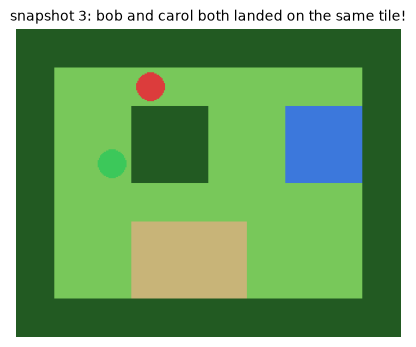

<Surface(320x256x32 SW)>

In [9]:
# bob and carol both aim for the SAME tile, (2, 3), sent essentially "at the same time" via asyncio.gather
print("bob before:  ", bob.latest_state[bob.player_id])
print("carol before:", carol.latest_state[carol.player_id])

await asyncio.gather(
    bob.move(1, 0),    # bob: (1, 3) -> (2, 3)
    carol.move(0, 1),  # carol: (2, 2) -> (2, 3) - the exact same destination tile as bob!
)
await asyncio.sleep(0.1)

print()
bob_after = bob.latest_state[bob.player_id]
carol_after = carol.latest_state[carol.player_id]
print("bob after:  ", bob_after)
print("carol after:", carol_after)
# compare just the (x, y) TILE, not the whole dict - bob/carol always have different name/color, only positions can clash
print("did both players end up standing on the exact same tile?",
      (bob_after["x"], bob_after["y"]) == (carol_after["x"], carol_after["y"]))

render_world_from_state(bob.latest_state, "snapshot 3: bob and carol both landed on the same tile!")

In [10]:
# a tiny STANDALONE demo of the "is this tile already taken" check we're missing above - not wired into the real server
def is_occupied_by_someone_else(players, moving_player_id, target_x, target_y):
    """Would ANOTHER player (not the one moving) already be standing on this exact tile?"""
    for other_id, other in players.items():
        if other_id != moving_player_id and other["x"] == target_x and other["y"] == target_y:
            return True
    return False


current_players = bob.latest_state
print("is (2, 3) occupied by someone other than bob?",
      is_occupied_by_someone_else(current_players, bob.player_id, 2, 3))
# if handle_client's "move" branch above had called this check BEFORE accepting the move, whichever of bob/carol's
# two move messages the server happened to process SECOND would have been rejected, avoiding the stack entirely -
# a completely natural extension of the authoritative-move check, and exactly what exercise 2 below asks you to build

is (2, 3) occupied by someone other than bob? True


## cleanup - disconnecting cleanly
* same habit as every networked lesson in this course: disconnect every client and close the server properly when we're done, recap lesson 34's `finally:`-based disconnect handling

In [11]:
print("before carol disconnects:", alice.latest_state)

await carol.disconnect()
await asyncio.sleep(0.1)  # give the server a moment to notice the closed connection and broadcast the update

print("after carol disconnects: ", alice.latest_state)
print("is carol's player_id still present?", carol.player_id in alice.latest_state)

await alice.disconnect()
await bob.disconnect()
rpg_server.close()
await rpg_server.wait_closed()
print("multiplayer RPG server closed, everyone disconnected cleanly")

before carol disconnects: {'player1': {'x': 3, 'y': 1, 'name': 'Alice', 'color': [220, 60, 60]}, 'player2': {'x': 2, 'y': 3, 'name': 'Bob', 'color': [60, 120, 220]}, 'player3': {'x': 2, 'y': 3, 'name': 'Carol', 'color': [60, 200, 90]}}


after carol disconnects:  {'player1': {'x': 3, 'y': 1, 'name': 'Alice', 'color': [220, 60, 60]}, 'player2': {'x': 2, 'y': 3, 'name': 'Bob', 'color': [60, 120, 220]}}
is carol's player_id still present? False


multiplayer RPG server closed, everyone disconnected cleanly


## quick comparison to other languages
* this exact shape of system - one (or many, region-sharded) authoritative server(s) holding the REAL world state, broadcasting the relevant bits to each connected client - is precisely how persistent-world multiplayer RPGs are built at enormous scale, from huge MMORPGs like World of Warcraft down to small "MMO-lite" indie RPGs
* dedicated game-backend platforms exist specifically so studios dont have to hand-roll all of this: **Photon**, **Colyseus** (Node.js, mentioned back in lesson 34) and **Nakama** all provide a ready-made version of the authoritative-server + state-broadcast pattern we just built by hand, with far more features (matchmaking, persistence, scaling across many server instances) than our little demo needs
* Unity's Netcode for GameObjects and Godot's high-level multiplayer API both have a built-in concept of "spawning" a network-synced object per connected player - conceptually that's the exact same idea as our `PLAYER_STATE[player_id] = {...}` entry, just wrapped in engine-level tooling instead of a plain python dict
* our "broadcast everything to everyone" approach is simple and great for learning, but real, bigger worlds almost always add **interest management** (only tell a client about players/objects actually near them) so bandwidth doesn't explode as the player count and map size grow - our exercise 3's distance-filtered chat below is a tiny taste of exactly that idea

## Exercises
1. our main demo already connects three players (Alice, Bob, Carol) - extend it by connecting a FOURTH simulated player on a fresh server, and confirm all four clients see each other in the broadcast state
2. implement the "no two players on the same tile" occupancy check we described and demoed conceptually above - wire it into a real server's move-handling, and demonstrate a move getting correctly blocked because another player is already standing on the target tile
3. add a simple distance-based filter so a chat/emote message is only delivered to players within N tiles of the sender, instead of broadcasting it to absolutely everyone connected
4. simulate one player disconnecting mid-session and confirm the remaining players' state correctly no longer includes them (recap lesson 34's disconnect handling)

In [12]:
# TODO: solve exercise 1 here (a fourth simulated player, confirm all four see each other)


# TODO: solve exercise 2 here (a "tile already occupied" check, wired into move-handling)


# TODO: solve exercise 3 here (distance-based filter for chat/emote messages)


# TODO: solve exercise 4 here (simulate a mid-session disconnect, confirm the state updates correctly)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

In [13]:
# --- a fresh server for the exercises, reusing WORLD_MAP/TILE_TYPES/is_walkable/is_occupied_by_someone_else from above ---
EX_PLAYER_STATE = {}
EX_CONNECTIONS = {}
EX_NEXT_NUM = [1]
EX_CHAT_RADIUS = 3  # exercise 3 - only players within this many tiles (manhattan distance) hear a chat message


async def ex_broadcast_state():
    message = (json.dumps({"type": "state", "players": dict(EX_PLAYER_STATE)}) + "\n").encode()
    for w in EX_CONNECTIONS.values():
        w.write(message)
        await w.drain()


async def ex_handle_client(reader, writer):
    hello = json.loads(await reader.readline())
    player_id = f"player{EX_NEXT_NUM[0]}"
    color = PLAYER_COLORS[(EX_NEXT_NUM[0] - 1) % len(PLAYER_COLORS)]
    EX_NEXT_NUM[0] += 1
    EX_PLAYER_STATE[player_id] = {"x": 1, "y": 1, "name": hello["name"], "color": list(color)}
    EX_CONNECTIONS[player_id] = writer
    writer.write((json.dumps({"type": "welcome", "player_id": player_id}) + "\n").encode())
    await writer.drain()
    await ex_broadcast_state()
    try:
        while True:
            line = await reader.readline()
            if not line:
                break
            request = json.loads(line)
            if request["type"] == "move":
                current = EX_PLAYER_STATE[player_id]
                new_x, new_y = current["x"] + request["dx"], current["y"] + request["dy"]
                # sample solution 2 - reject the move if the tile is a wall OR already occupied by someone else
                target_free = not is_occupied_by_someone_else(EX_PLAYER_STATE, player_id, new_x, new_y)
                if is_walkable(new_x, new_y) and target_free:
                    current["x"], current["y"] = new_x, new_y
                await ex_broadcast_state()
            elif request["type"] == "chat":
                # sample solution 3 - only deliver this chat message to players within EX_CHAT_RADIUS of the SENDER
                sender_pos = EX_PLAYER_STATE[player_id]
                message = (json.dumps({
                    "type": "chat", "player_id": player_id, "name": sender_pos["name"], "text": request["text"],
                }) + "\n").encode()
                for other_id, other_writer in EX_CONNECTIONS.items():
                    other_pos = EX_PLAYER_STATE[other_id]
                    distance = abs(other_pos["x"] - sender_pos["x"]) + abs(other_pos["y"] - sender_pos["y"])
                    if distance <= EX_CHAT_RADIUS:
                        other_writer.write(message)
                        await other_writer.drain()
    finally:
        # sample solution 4 - the SAME finally-based disconnect cleanup as the main server above
        EX_PLAYER_STATE.pop(player_id, None)
        EX_CONNECTIONS.pop(player_id, None)
        await ex_broadcast_state()


ex_server = await asyncio.start_server(ex_handle_client, "127.0.0.1", 0)
ex_port = ex_server.sockets[0].getsockname()[1]


class ExRPGSimClient(RPGSimClient):
    """Same RPGSimClient behaviour, just pointed at our fresh exercise server instead."""
    async def connect(self):
        self.reader, self.writer = await asyncio.open_connection("127.0.0.1", ex_port)
        self.writer.write((json.dumps({"type": "hello", "name": self.name}) + "\n").encode())
        await self.writer.drain()
        welcome = json.loads(await self.reader.readline())
        self.player_id = welcome["player_id"]
        self._listen_task = asyncio.create_task(self._listen_forever())


# sample solution 1 - a FOURTH player, confirming everyone still sees everyone else on this fresh server
p1, p2, p3, p4 = ExRPGSimClient("P1"), ExRPGSimClient("P2"), ExRPGSimClient("P3"), ExRPGSimClient("P4")
await p1.connect(); await p2.connect(); await p3.connect(); await p4.connect()
await asyncio.sleep(0.15)
print("all four players visible to p1?",
      set(p1.latest_state) == {p1.player_id, p2.player_id, p3.player_id, p4.player_id})

# sample solution 2 - p1 moves off the spawn tile, then p2 tries to step onto p1's NEW tile and should get rejected
await p1.move(1, 0)  # p1: (1, 1) -> (2, 1)
await asyncio.sleep(0.1)
p2_before = dict(p2.latest_state[p2.player_id])
await p2.move(1, 0)  # p2 also tries (1, 1) -> (2, 1) - the exact tile p1 is NOW standing on
await asyncio.sleep(0.1)
p2_after = p2.latest_state[p2.player_id]
print("p2 before trying to step onto p1's tile:", p2_before, "| after (should be unchanged):", p2_after,
      "| occupancy check worked?", p2_before == p2_after)

# sample solution 3 - move p3 far away (out of chat radius) and p4 nearby (inside chat radius), then send a chat
for _ in range(3):
    await p3.move(0, 1)   # p3 heads down the left corridor, away from everyone else
    await asyncio.sleep(0.05)
for _ in range(6):
    await p3.move(1, 0)   # then far along the open corridor, well outside our EX_CHAT_RADIUS of 3
    await asyncio.sleep(0.05)
await p4.move(0, 1)   # p4 just steps one tile down, staying close to p1
await asyncio.sleep(0.1)

print("p1 position:", p1.latest_state[p1.player_id], "| p3 position:", p3.latest_state[p3.player_id],
      "| p4 position:", p4.latest_state[p4.player_id])

await p1.say("hi nearby folks!")
await asyncio.sleep(0.1)
print("did p4 (nearby) receive the chat?", any(c["text"] == "hi nearby folks!" for c in p4.chat_log))
print("did p3 (far away) receive the chat?", any(c["text"] == "hi nearby folks!" for c in p3.chat_log))

# sample solution 4 - disconnect p3 mid-session, confirm the remaining players' state correctly drops them
await p3.disconnect()
await asyncio.sleep(0.1)
print("p3 still present in p1's state after disconnecting?", p3.player_id in p1.latest_state)
print("p1, p2, p4 still present?", {p1.player_id, p2.player_id, p4.player_id}.issubset(p1.latest_state))

await p1.disconnect(); await p2.disconnect(); await p4.disconnect()
ex_server.close()
await ex_server.wait_closed()
print("exercise server closed")

all four players visible to p1? True


p2 before trying to step onto p1's tile: {'x': 1, 'y': 1, 'name': 'P2', 'color': [60, 120, 220]} | after (should be unchanged): {'x': 1, 'y': 1, 'name': 'P2', 'color': [60, 120, 220]} | occupancy check worked? True


p1 position: {'x': 2, 'y': 1, 'name': 'P1', 'color': [220, 60, 60]} | p3 position: {'x': 7, 'y': 4, 'name': 'P3', 'color': [60, 200, 90]} | p4 position: {'x': 1, 'y': 2, 'name': 'P4', 'color': [230, 190, 60]}
did p4 (nearby) receive the chat? True
did p3 (far away) receive the chat? False


p3 still present in p1's state after disconnecting? False
p1, p2, p4 still present? True
exercise server closed


* congratulation you finished this lesson

## what we learned
* how lesson 31's single-player RPG world (tile map, collision, walking around) and lessons 33/34's generic multiplayer networking (authoritative server, broadcast-on-change, `SimClient`-style clients) combine into one real (simulated) multiplayer RPG
* the server owns the ONE real copy of the map and of every connected player's position/name/color - clients only ever get told what's true, they never change it directly
* an `RPGSimClient` helper with a background listener task, sending `move`/`chat` requests and reconstructing "what this player currently sees" purely from received broadcasts
* proving multiple clients converge on identical, correct shared state, including a deliberately illegal move (into a wall) getting rejected for one player without affecting anyone else
* a chat/emote system as our RPG-specific multiplayer feature on top of plain movement
* rendering pygame snapshots straight from a CLIENT's own received state, never from the server's internals directly - exactly like a real multiplayer game client would
* why two players moving onto the same tile "at once" causes no race condition (asyncio processes one message at a time), but CAN still let both moves succeed and stack, unless you add an explicit occupancy check
* how this exact pattern scales up to real MMORPGs and MMO-lite indie games, and the ready-made backend platforms (Photon, Colyseus, Nakama) and engine features (Unity Netcode, Godot's high-level multiplayer API) built specifically for it